CERT Dataset — Exploratory Data Analysis

Import Libraries

In [2]:
import sys
import os

# Add project root directory to path
sys.path.append(os.path.abspath(".."))

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import config

%matplotlib inline

Load Processed Data

In [4]:
logs = {
    name: pd.read_parquet(config.PROCESSED_DIR / f"{name}_processed.parquet")
    for name in config.LOG_FILES
}

Basic Overview

In [5]:
for name, df in logs.items():
    print(f"\n{name.upper()}")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("Nulls:\n", df.isnull().sum())


LOGON
Shape: (854859, 11)
Columns: ['id', 'user', 'pc', 'activity', 'timestamp', 'hour', 'day_of_week', 'is_weekend', 'is_after_hours', 'date_only', 'log_source']
Nulls:
 id                0
user              0
pc                0
activity          0
timestamp         0
hour              0
day_of_week       0
is_weekend        0
is_after_hours    0
date_only         0
log_source        0
dtype: int64

DEVICE
Shape: (405380, 11)
Columns: ['id', 'user', 'pc', 'activity', 'timestamp', 'hour', 'day_of_week', 'is_weekend', 'is_after_hours', 'date_only', 'log_source']
Nulls:
 id                0
user              0
pc                0
activity          0
timestamp         0
hour              0
day_of_week       0
is_weekend        0
is_after_hours    0
date_only         0
log_source        0
dtype: int64

EMAIL
Shape: (2629979, 17)
Columns: ['id', 'user', 'pc', 'to', 'cc', 'bcc', 'from', 'size', 'attachments', 'content', 'timestamp', 'hour', 'day_of_week', 'is_weekend', 'is_after_hours', 'd

Null Analysis

In [6]:
for name, df in logs.items():
    print(f"\n{name}")
    print((df.isnull().sum() / len(df) * 100).round(2))


logon
id                0.0
user              0.0
pc                0.0
activity          0.0
timestamp         0.0
hour              0.0
day_of_week       0.0
is_weekend        0.0
is_after_hours    0.0
date_only         0.0
log_source        0.0
dtype: float64

device
id                0.0
user              0.0
pc                0.0
activity          0.0
timestamp         0.0
hour              0.0
day_of_week       0.0
is_weekend        0.0
is_after_hours    0.0
date_only         0.0
log_source        0.0
dtype: float64

email
id                 0.00
user               0.00
pc                 0.00
to                 0.00
cc                61.49
bcc               84.14
from               0.00
size               0.00
attachments        0.00
content            0.00
timestamp          0.00
hour               0.00
day_of_week        0.00
is_weekend         0.00
is_after_hours     0.00
date_only          0.00
log_source         0.00
dtype: float64

file
id                0.0
user         

User Activity Summary

In [7]:
summary = []
for name, df in logs.items():
    if "user" in df.columns:
        counts = df.groupby("user").size().rename(name)
        summary.append(counts)

summary_df = pd.concat(summary, axis=1).fillna(0)
summary_df["total"] = summary_df.sum(axis=1)
summary_df.sort_values("total", ascending=False).head()

,logon,device,email,file,http,total
user,,,,,,
mss0001,960,0.0,12034,0.0,138000,150994.0
kbp0008,1197,0.0,9145,0.0,103800,114142.0
hcs0003,692,2006.0,9097,3045.0,98610,113450.0
dlm0051,1367,7533.0,7573,10673.0,82840,109986.0
hth0007,961,0.0,9116,0.0,98610,108687.0


Plot 1 — Hourly Distribution

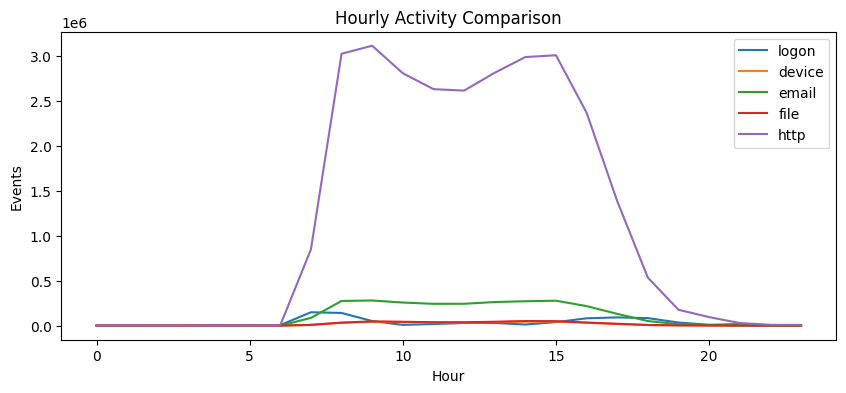

In [8]:
plt.figure(figsize=(10,4))
for name, df in logs.items():
    if "hour" in df.columns:
        df["hour"].value_counts().sort_index().plot(label=name)

plt.legend()
plt.title("Hourly Activity Comparison")
plt.xlabel("Hour")
plt.ylabel("Events")
plt.show()

Plot 2 — User Activity Distribution

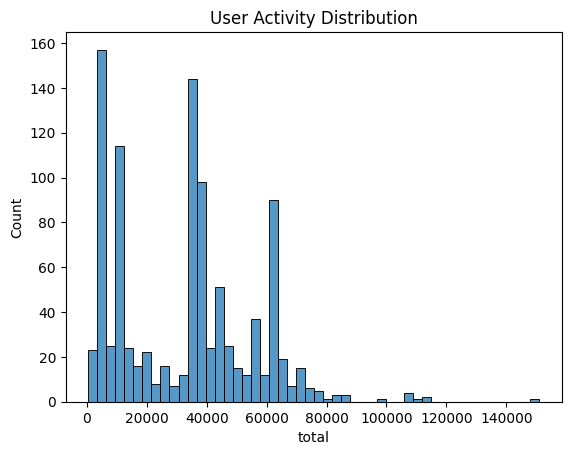

In [9]:
sns.histplot(summary_df["total"], bins=50)
plt.title("User Activity Distribution")
plt.show()

After-hours Analysis

In [10]:
for name, df in logs.items():
    if "is_after_hours" in df.columns:
        print(name, df["is_after_hours"].mean() * 100)

logon 40.21739257585169
device 8.398539641817553
email 6.360507061082997
file 8.394208909266778
http 6.015282954748194
